In [107]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as  mpl
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression ,SGDClassifier
from sklearn.model_selection import train_test_split , StratifiedKFold , cross_val_predict, cross_val_score ,GridSearchCV
from sklearn.metrics import confusion_matrix, precision_recall_curve , precision_score , recall_score
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

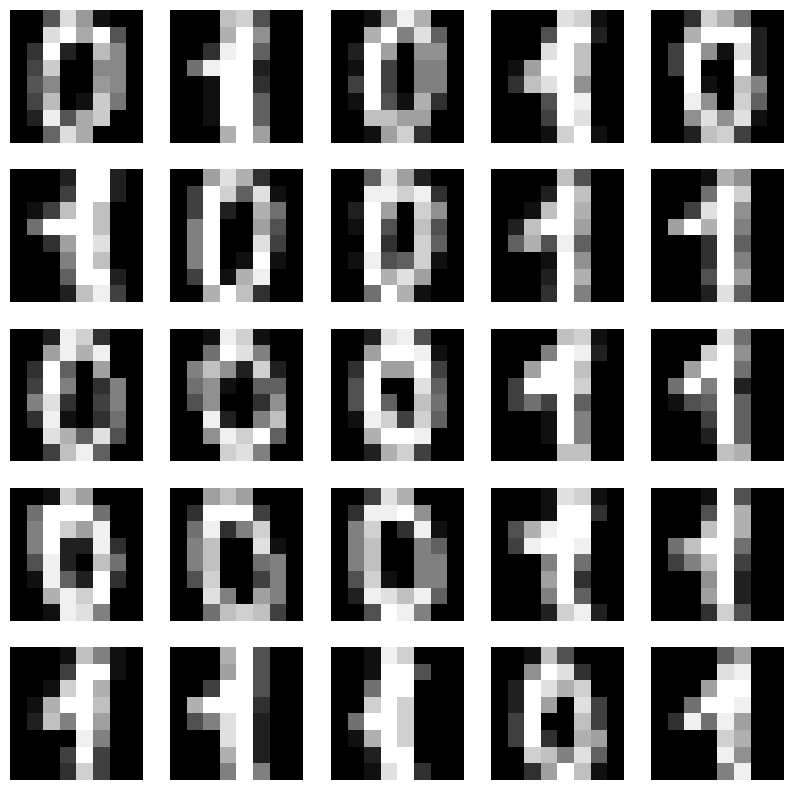

In [27]:
X , y = load_digits( return_X_y=True , n_class = 2 )

fig , ax = plt.subplots( 5,5 , figsize = ( 10,10 ) )
ax = ax.flatten()
for i in range(25):
  ax[i].imshow(X[i].reshape(8,8) , cmap = 'gray')
  ax[i].axis('off')
plt.show()

In [33]:
skfolds = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 26 )
X_train ,X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 26  , stratify=y, shuffle=True )
model = LogisticRegression()
scores = cross_val_score(model, X_train , y_train, scoring ='recall', cv = skfolds )
scores

array([1., 1., 1., 1., 1.])

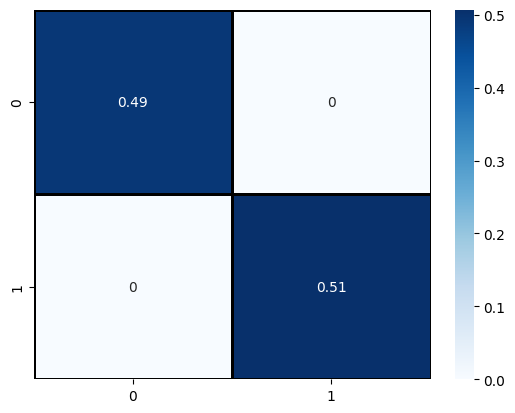

In [37]:
y_train_pred = cross_val_predict(model, X_train , y_train, cv = skfolds )
p , r , thr = precision_recall_curve(y_train, y_train_pred, pos_label=1)
cm = confusion_matrix(y_train, y_train_pred , normalize = 'all')
plt.figure()
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

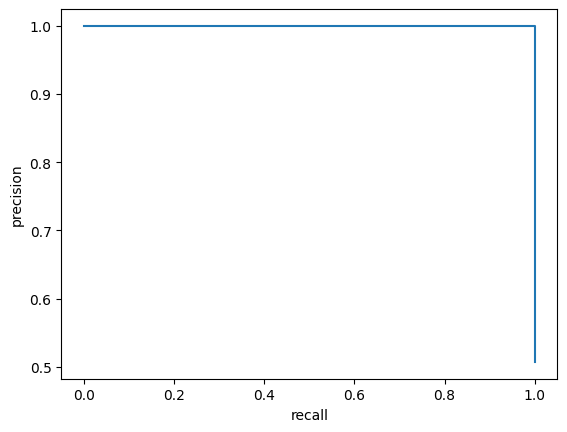

In [45]:
plt.figure()
plt.plot(r, p)
plt.xlabel('recall')
plt.ylabel('precision')
plt.show()

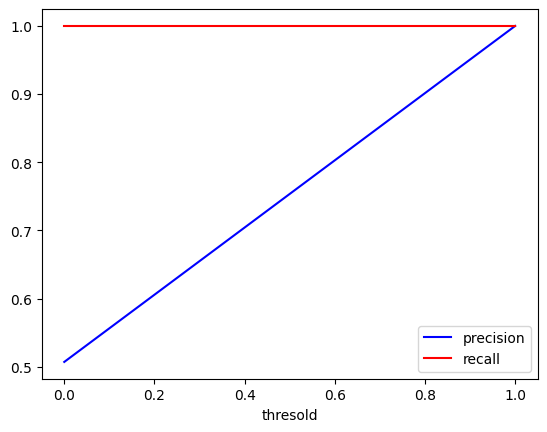

In [43]:
plt.figure()
plt.plot( thr, p[:-1], color = 'blue' , label = 'precision' )
plt.plot( thr, r[:-1], color = 'red' , label = 'recall' )
plt.legend()
plt.xlabel('thresold')
plt.show()

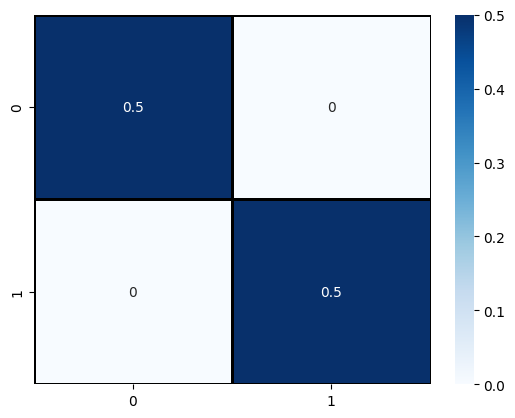

In [44]:
model.fit( X_train , y_train )
y_pred = model.predict( X_test )
cm = confusion_matrix(y_test, y_pred , normalize = 'all')
plt.figure()
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

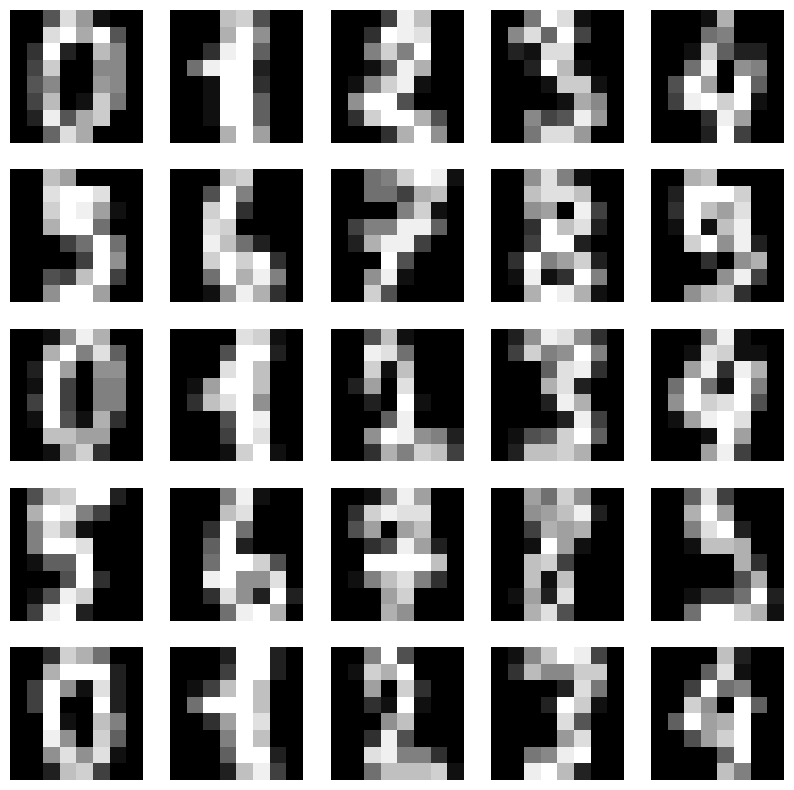

In [67]:
X , y = load_digits( return_X_y=True , n_class = 10 )
skfolds = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 26 )
X_train ,X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 26  , stratify=y, shuffle=True )

fig , ax = plt.subplots( 5,5 , figsize = ( 10,10 ) )
ax = ax.flatten()
for i in range(25):
  ax[i].imshow(X[i].reshape(8,8) , cmap = 'gray')
  ax[i].axis('off')
plt.show()

In [72]:
model = LogisticRegression(max_iter = 1000)
param_grid ={ 'multi_class' : [ 'ovr' , 'multinomial' ] }
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=skfolds, scoring= 'precision_macro')
grid_search.fit(X_train, y_train)
import warnings
warnings.filterwarnings('ignore')

In [73]:
grid_search.best_estimator_

LogisticRegression(multi_class='multinomial')

In [74]:
grid_search.best_score_

np.float64(0.962465103978045)

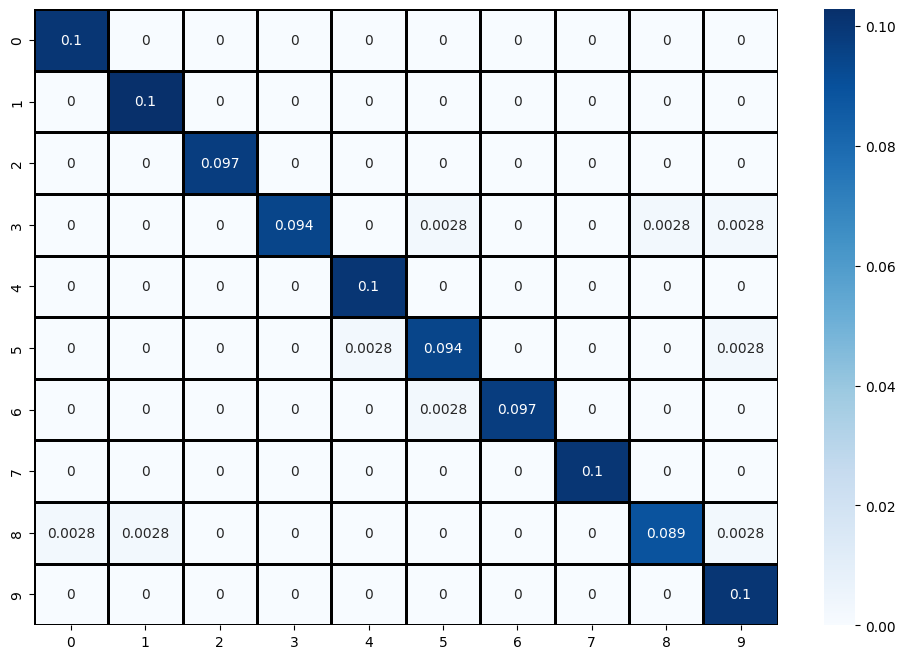

In [78]:
model = grid_search.best_estimator_

y_pred = model.predict( X_test )
cm = confusion_matrix(y_test, y_pred , normalize = 'all')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

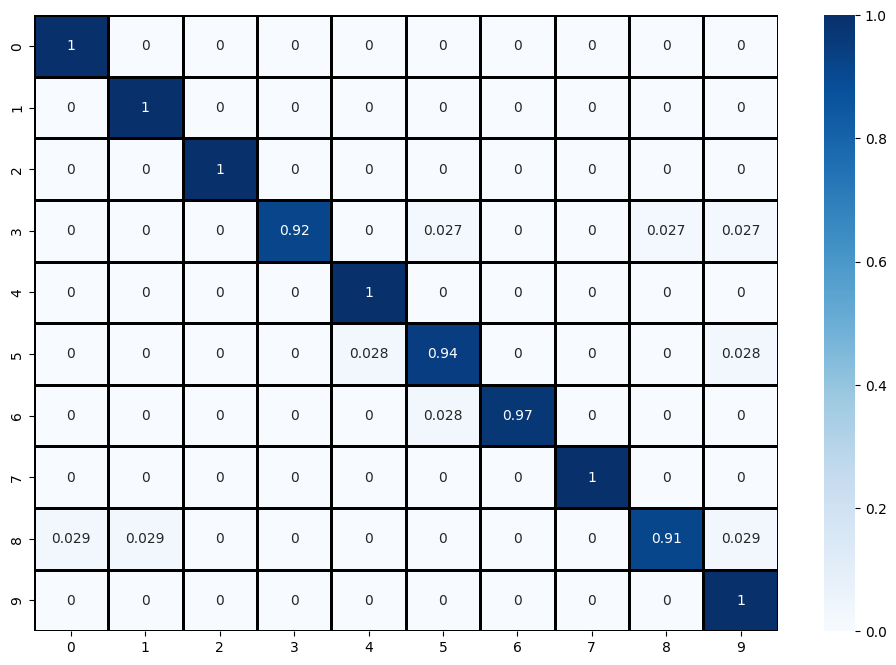

In [79]:
cm = confusion_matrix(y_test, y_pred , normalize = 'true')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

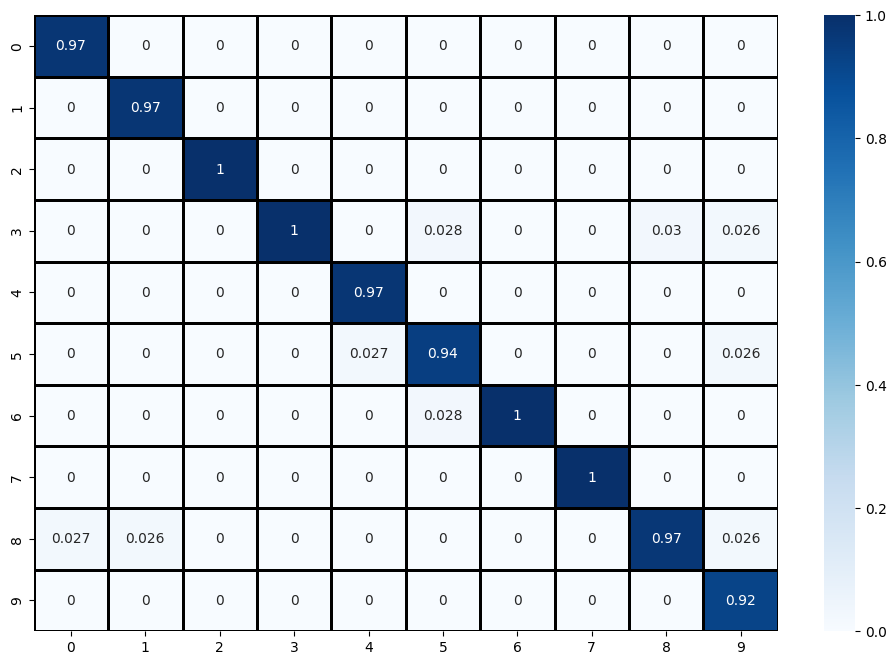

In [80]:
cm = confusion_matrix(y_test, y_pred , normalize = 'pred')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

Okay so the above code is done on logistic regression with the one versus all (treating each classes as zero when treating one class as 1 ) and repeat for all classes in the dataset and picks the highest score , the multinomial selects the baseline and computes one and only log loss and predicts probability using the softmax, the one versus one makes possible fair treating as binary classificaiton of each pair and selects with the most voting

In [93]:
X,y = load_digits(return_X_y=True, n_class=10)
skfolds = StratifiedKFold( n_splits = 5 , shuffle = True , random_state = 26 )

X_train ,X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 26  , stratify=y, shuffle=True )

model = SGDClassifier(loss = 'log_loss' , max_iter = 1000)
model.fit(X_train, y_train)

SGDClassifier(loss='log_loss')

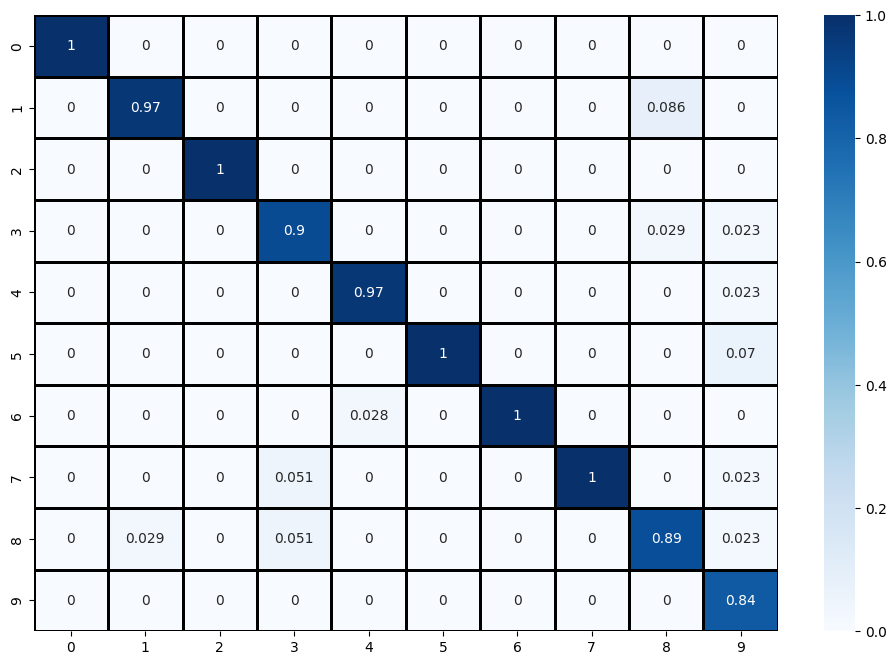

In [96]:
y_pred = model.predict( X_test )
cm = confusion_matrix(y_test, y_pred , normalize = 'pred')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

In [99]:
model.predict( X_test[0:2] )

array([6, 3])

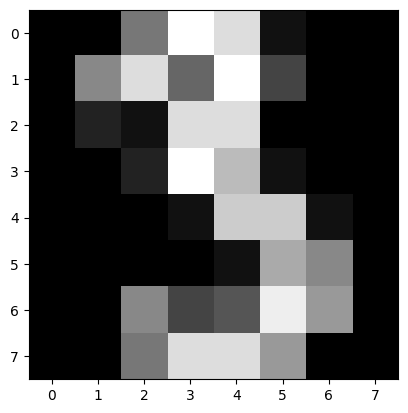

In [101]:
plt.figure()

plt.imshow( X[3].reshape(8,8), cmap = 'gray' )
plt.show()

the sgd works on stochastic gradient descent and classifies on softmax function on default

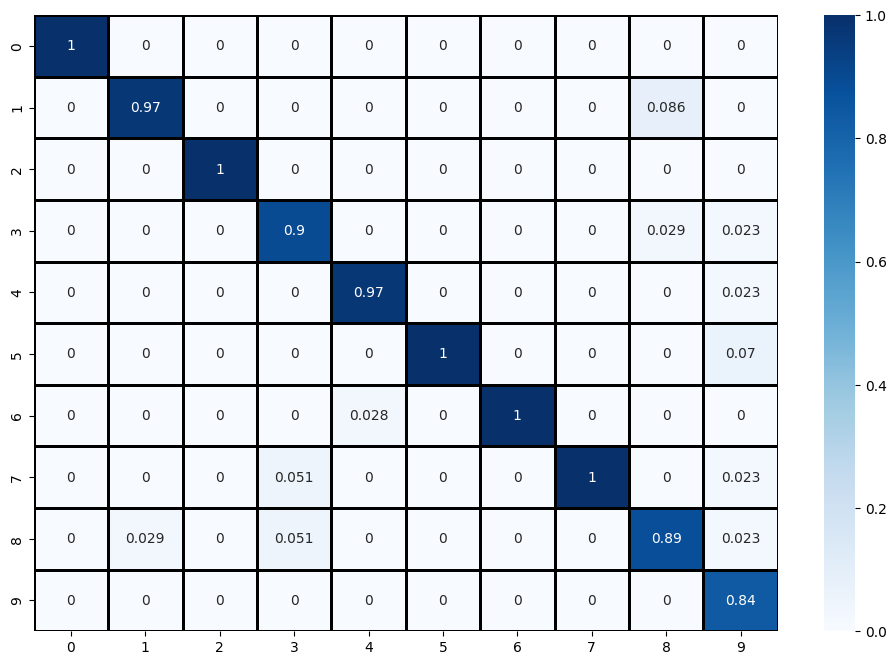

In [106]:
model_2 = OneVsRestClassifier(SGDClassifier(loss = 'log_loss' , max_iter = 1000))
model_2.fit(X_train,y_train)
y_pred = model.predict( X_test )
cm = confusion_matrix(y_test, y_pred , normalize = 'pred')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()

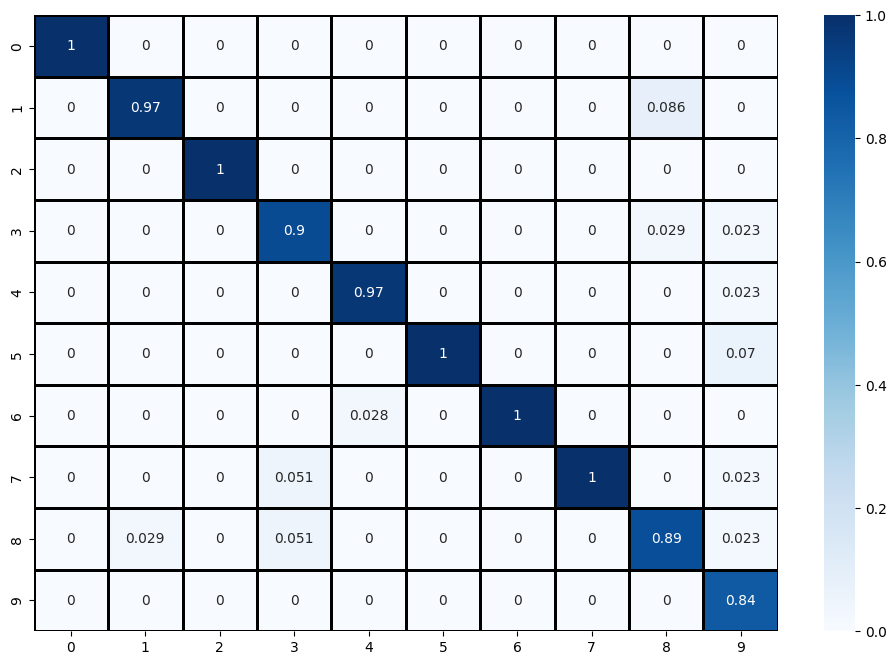

In [109]:
model_2 = OneVsOneClassifier(SGDClassifier(loss = 'log_loss' , max_iter = 500))
model_2.fit(X_train,y_train)
y_pred = model.predict( X_test )
cm = confusion_matrix(y_test, y_pred , normalize = 'pred')
plt.figure(figsize = (12,8))
sns.heatmap( cm , annot=True, cmap = 'Blues' , linecolor ='black', linewidth = 1 )
plt.show()